# 👥 K-Nearest Neighbors (KNN) — Customer Churn Prediction

---

## 🎯 What Will You Learn?

- Understand the **intuition** behind KNN (no math required!)
- Learn how to find the **best value of K**
- Build and evaluate a KNN classifier
- Compare KNN with Logistic Regression

---

## 📖 Table of Contents
1. What is KNN?
2. Loading and Preparing the Data
3. Finding the Best K (Elbow Method)
4. Building the KNN Model
5. Making Predictions
6. Evaluating the Model
7. Comparing KNN vs Logistic Regression
8. Key Takeaways


---
## 1. 🤝 What is K-Nearest Neighbors (KNN)?

### Simple Real-World Analogy 🏘️

Imagine you just moved to a new city and someone asks: **"Are you likely to churn from your internet provider?"**

You don't have a history with this provider. So what do you do?

**You look at your NEIGHBORS!**

If the 5 most similar people to you (same age, same contract, same charges) all churned → you probably will too!

If 4 out of 5 similar people stayed → you'll probably stay too!

**That's exactly what KNN does!**

### How KNN Works (Step by Step)

```
Step 1: New customer arrives → "Will this person churn?"
Step 2: Find the K most SIMILAR customers in our training data
Step 3: Count votes: how many of those K customers churned?
Step 4: If majority churned → predict CHURN. Otherwise → predict STAY.
```

### What is K?

**K** is the number of neighbors we look at:
- **K=1:** Look at only the 1 most similar customer (can be noisy)
- **K=5:** Look at the 5 most similar customers (more stable)
- **K=10:** Look at the 10 most similar customers (smoother)

```
  Small K → more flexible (can overfit)
  Large K → more general (can underfit)
  Finding the RIGHT K is the key challenge!
```

### How Do We Measure "Similarity"?

We use **distance** — just like measuring how far apart two points are on a map!
- Customer A: Age=30, Charges=50
- Customer B: Age=32, Charges=48 → They are CLOSE (similar)
- Customer C: Age=60, Charges=100 → They are FAR (different)

The most common distance is **Euclidean distance** (straight-line distance between two points).


In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                              classification_report, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Libraries imported!")

✅ Libraries imported!


---
## 2. 📂 Loading and Preparing the Data

We use the same dataset as Logistic Regression so we can compare results fairly.

In [2]:
# Load data
df = pd.read_csv('data/customer_churn.csv')
print(f"Dataset shape: {df.shape}")
df.head(3)

Dataset shape: (5000, 15)


,customer_id,age,gender,city,education,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_products,has_credit_card,is_active_member,estimated_salary,churned
0,10000,46.0,Male,Bengaluru,Bachelors,40,Month-to-month,Electronic check,16.90,686.72,3,1,0,55083.68,1
1,10001,28.0,Female,Chennai,Masters,22,One year,Credit card,88.73,NaN,2,1,0,75325.39,0
2,10002,52.0,Female,Mumbai,Bachelors,7,Two year,Mailed check,67.45,449.61,1,1,1,57584.71,0


In [3]:
# --- Preprocessing (same steps as Logistic Regression) ---

# Drop customer_id (not useful for prediction)
df_model = df.drop(['customer_id'], axis=1)

# Fill missing values with median
numeric_cols = df_model.select_dtypes(include=[np.number]).columns
df_model[numeric_cols] = df_model[numeric_cols].fillna(df_model[numeric_cols].median())

# Encode text columns
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Separate features and target
X = df_model.drop('churned', axis=1)
y = df_model['churned']

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (VERY IMPORTANT for KNN — distances are meaningless without scaling!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data prepared!")
print(f"   Training samples: {len(X_train)}")
print(f"   Testing samples:  {len(X_test)}")

✅ Data prepared!
   Training samples: 4000
   Testing samples:  1000


### ⚠️ Why Scaling is CRITICAL for KNN

Imagine comparing two customers:
- Feature 1: Age (range: 18–70) 
- Feature 2: Total Charges (range: 100–10,000)

Without scaling, **Total Charges dominates** the distance calculation because it has larger numbers. Age would barely matter!

With scaling, **all features contribute equally** to the distance.

---
## 3. 🎯 Finding the Best K — The Elbow Method

We need to find the **optimal K value** that gives the best accuracy.

We try K from 1 to 30 and see which gives the best accuracy on the test set.

In [4]:
# Test different K values and record accuracy
train_accuracies = []
test_accuracies = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Find the best K
best_k = k_range[np.argmax(test_accuracies)]
best_accuracy = max(test_accuracies)
print(f"Best K = {best_k} with Test Accuracy = {best_accuracy*100:.2f}%")

Best K = 7 with Test Accuracy = 90.90%


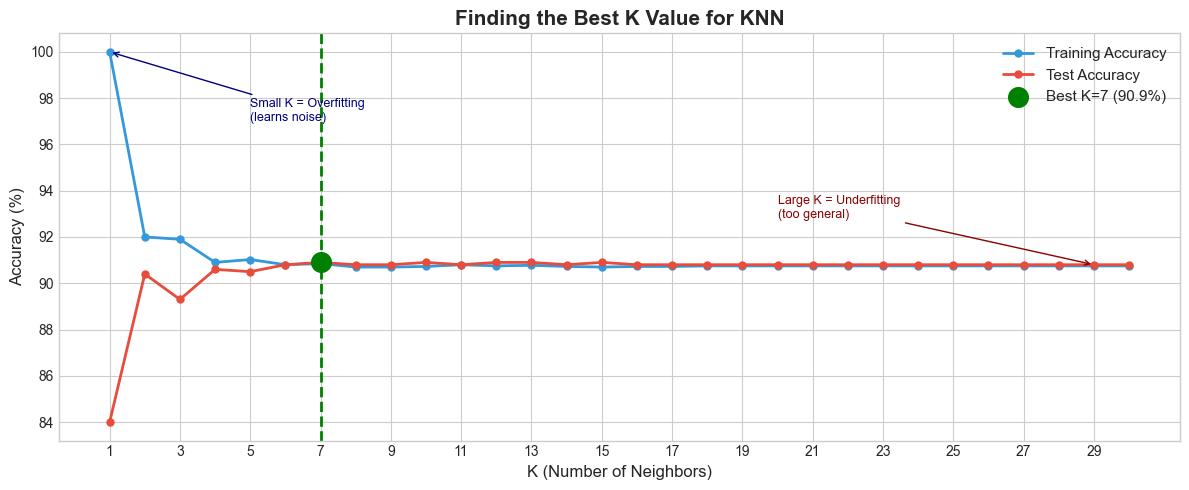


✅ Best K = 7


In [5]:
# Plot K vs Accuracy
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(k_range, [a*100 for a in train_accuracies], 'b-o', markersize=5,
        linewidth=2, label='Training Accuracy', color='#3498db')
ax.plot(k_range, [a*100 for a in test_accuracies], 'r-o', markersize=5,
        linewidth=2, label='Test Accuracy', color='#e74c3c')

# Highlight the best K
ax.axvline(x=best_k, color='green', linestyle='--', linewidth=2)
ax.scatter([best_k], [best_accuracy*100], color='green', s=200, zorder=5, 
           label=f'Best K={best_k} ({best_accuracy*100:.1f}%)')

ax.set_xlabel('K (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Finding the Best K Value for KNN', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(range(1, 31, 2))

# Annotations
ax.annotate('Small K = Overfitting\n(learns noise)', xy=(1, train_accuracies[0]*100),
            xytext=(5, train_accuracies[0]*100 - 3), fontsize=9, color='navy',
            arrowprops=dict(arrowstyle='->', color='navy'))
ax.annotate('Large K = Underfitting\n(too general)', xy=(29, test_accuracies[28]*100),
            xytext=(20, test_accuracies[28]*100 + 2), fontsize=9, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))

plt.tight_layout()
plt.savefig('knn_best_k.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"\n✅ Best K = {best_k}")

### 💡 Understanding the Overfitting vs Underfitting Trade-off

```
K=1 (very small):
  - Memorizes every training example perfectly → 100% training accuracy
  - But fails on new data → LOW test accuracy (OVERFITTING)

K=30 (very large):
  - Looks at too many neighbors, becomes too general
  - Both training and test accuracy drop (UNDERFITTING)

Best K (middle ground):
  - Good balance: generalizes well without being too rigid
```

---
## 4. 🤖 Building the KNN Model with Best K

In [6]:
# Build the final KNN model with the best K
knn_model = KNeighborsClassifier(
    n_neighbors=best_k,    # Use the best K we found
    metric='euclidean',    # Use straight-line distance
    weights='uniform'      # All neighbors vote equally
)

# Train the model
print(f"🚀 Training KNN with K={best_k}...")
knn_model.fit(X_train_scaled, y_train)
print("✅ KNN model trained!")

🚀 Training KNN with K=7...
✅ KNN model trained!


---
## 5. 🔮 Making Predictions

In [7]:
# Make predictions
y_pred = knn_model.predict(X_test_scaled)
y_prob = knn_model.predict_proba(X_test_scaled)

print("Sample predictions (first 10 customers):")
print(f"{'Actual':<10} {'Predicted':<12} {'Churn Prob':<15} {'Correct?'}")
print("-" * 50)
for i in range(10):
    actual = y_test.values[i]
    predicted = y_pred[i]
    prob = y_prob[i][1]
    status = "✅" if actual == predicted else "❌"
    print(f"{actual:<10} {predicted:<12} {prob:.3f}          {status}")

Sample predictions (first 10 customers):
Actual     Predicted    Churn Prob      Correct?
--------------------------------------------------
0          0            0.286          ✅
0          0            0.143          ✅
0          0            0.000          ✅
1          0            0.000          ❌
0          0            0.143          ✅
0          0            0.143          ✅
0          0            0.000          ✅
0          0            0.143          ✅
0          0            0.000          ✅
0          0            0.143          ✅


---
## 6. 📏 Evaluating the Model

In [8]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob[:, 1])

print(f"🎯 KNN Model Results (K={best_k}):")
print(f"   Accuracy:  {accuracy*100:.2f}%")
print(f"   ROC-AUC:   {roc_auc:.4f}")
print()
print("Detailed Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

🎯 KNN Model Results (K=7):
   Accuracy:  90.90%
   ROC-AUC:   0.5686

Detailed Report:
              precision    recall  f1-score   support

      Stayed       0.91      1.00      0.95       908
     Churned       0.57      0.04      0.08        92

    accuracy                           0.91      1000
   macro avg       0.74      0.52      0.52      1000
weighted avg       0.88      0.91      0.87      1000



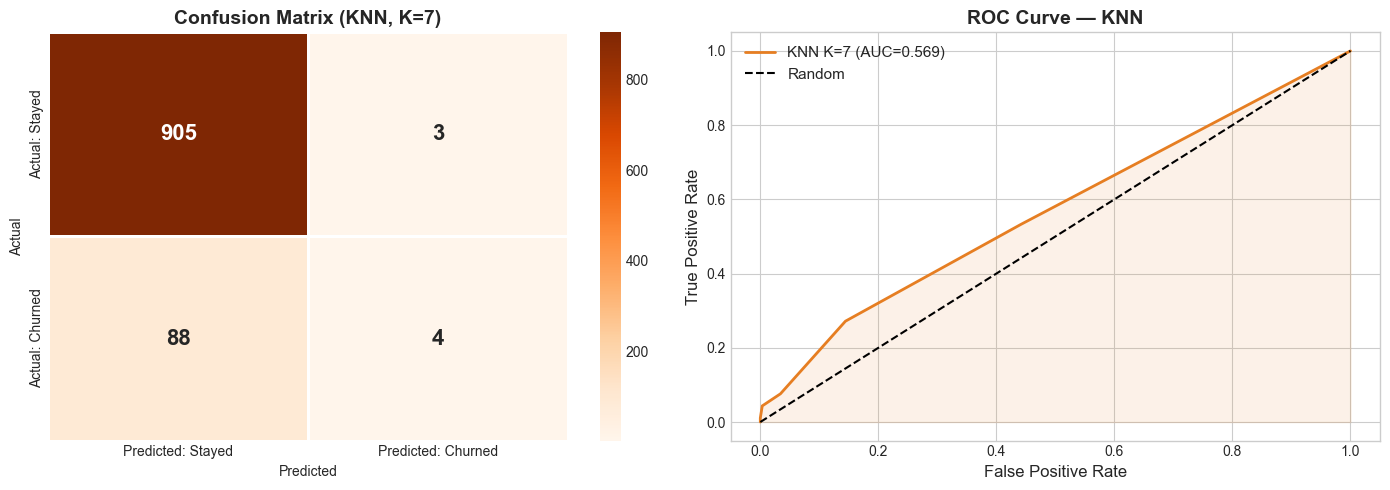

In [9]:
# Visualize Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Predicted: Stayed', 'Predicted: Churned'],
            yticklabels=['Actual: Stayed', 'Actual: Churned'],
            linewidths=2, linecolor='white', annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title(f'Confusion Matrix (KNN, K={best_k})', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
axes[1].plot(fpr, tpr, color='#e67e22', lw=2, label=f'KNN K={best_k} (AUC={roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e67e22')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve — KNN', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('knn_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 7. ⚖️ Comparing KNN vs Logistic Regression

In [10]:
# Train Logistic Regression for comparison
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob[:, 1])

knn_accuracy = accuracy
knn_auc = roc_auc

# Comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', f'KNN (K={best_k})'],
    'Accuracy (%)': [f'{lr_accuracy*100:.2f}', f'{knn_accuracy*100:.2f}'],
    'ROC-AUC': [f'{lr_auc:.4f}', f'{knn_auc:.4f}'],
    'Interpretable?': ['Yes (easy)', 'No (black box)'],
    'Speed (large data)': ['Fast', 'Slow (searches all data)'],
    'Needs Scaling?': ['Yes', 'Yes (critical!)']
})

print("Model Comparison:")
print(comparison_df.to_string(index=False))

Model Comparison:
              Model Accuracy (%) ROC-AUC Interpretable?       Speed (large data)  Needs Scaling?
Logistic Regression        90.80  0.6978     Yes (easy)                     Fast             Yes
          KNN (K=7)        90.90  0.5686 No (black box) Slow (searches all data) Yes (critical!)


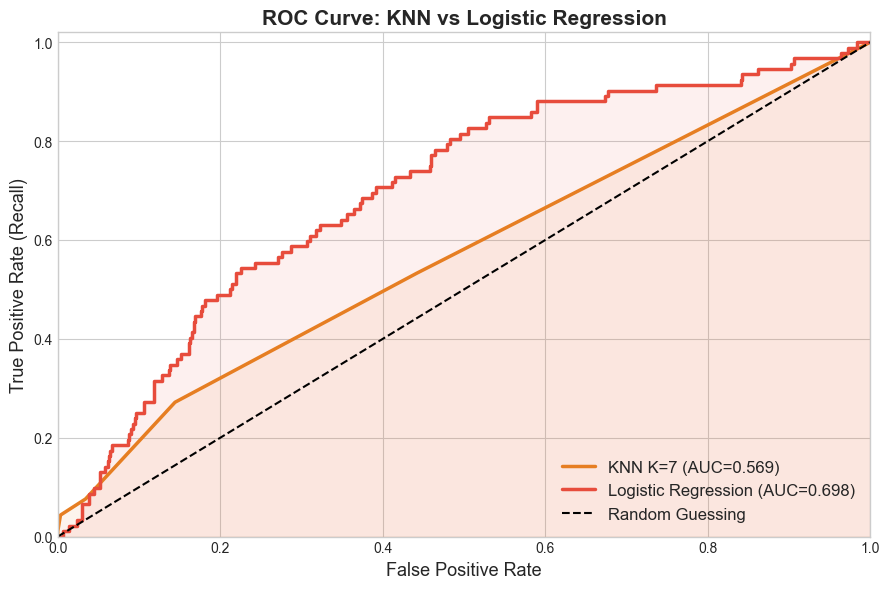

In [11]:
# ROC Curve Comparison
fig, ax = plt.subplots(figsize=(9, 6))

# KNN ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob[:, 1])
ax.plot(fpr_knn, tpr_knn, lw=2.5, color='#e67e22',
        label=f'KNN K={best_k} (AUC={knn_auc:.3f})')

# LR ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob[:, 1])
ax.plot(fpr_lr, tpr_lr, lw=2.5, color='#e74c3c',
        label=f'Logistic Regression (AUC={lr_auc:.3f})')

# Baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guessing')

ax.fill_between(fpr_knn, tpr_knn, alpha=0.08, color='#e67e22')
ax.fill_between(fpr_lr, tpr_lr, alpha=0.08, color='#e74c3c')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=13)
ax.set_title('ROC Curve: KNN vs Logistic Regression', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('knn_vs_lr_roc.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 8. 🎓 Key Takeaways

### KNN Summary:
- **Idea:** Classify based on the K most similar data points
- **Distance:** Uses Euclidean distance (straight-line distance)
- **K selection:** Too small = overfitting, Too large = underfitting
- **Scaling:** Absolutely required — unscaled data gives meaningless distances

### When to Use KNN?
| ✅ KNN Works Well | ⚠️ Avoid KNN When |
|---|---|
| Small to medium datasets | Very large datasets (slow!) |
| Non-linear patterns | High-dimensional data (distance curse) |
| Quick prototyping | Real-time prediction needed |
| No assumptions about data distribution | Need interpretability |

### KNN vs Logistic Regression
| | KNN | Logistic Regression |
|---|---|---|
| **How it works** | Memory-based (stores all data) | Model-based (finds formula) |
| **Interpretability** | Low (black box) | High (coefficients explain) |
| **Speed at prediction** | Slow (compares all data) | Fast (just a formula) |
| **Handles non-linearity** | Yes | No (assumes linear boundary) |

### Next Steps:
Try **Decision Trees** to see how a completely different approach works!


In [12]:
# Final Summary
print("=" * 55)
print("           KNN MODEL SUMMARY")
print("=" * 55)
print(f"  Dataset:      Customer Churn")
print(f"  Best K value: {best_k}")
print(f"  Accuracy:     {knn_accuracy*100:.2f}%")
print(f"  ROC-AUC:      {knn_auc:.4f}")
print(f"  vs LR Acc:    {lr_accuracy*100:.2f}%")
print(f"  vs LR AUC:    {lr_auc:.4f}")
print("=" * 55)

           KNN MODEL SUMMARY
  Dataset:      Customer Churn
  Best K value: 7
  Accuracy:     90.90%
  ROC-AUC:      0.5686
  vs LR Acc:    90.80%
  vs LR AUC:    0.6978
